In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from google.colab import drive
from google.colab import files

In [ ]:
#I used this for random forests - Abby
import os
import zipfile

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import precision_score, recall_score, roc_auc_score


## Read Dataset

In [ ]:
# Load an CSV file
file_path = 'https://www.dropbox.com/scl/fi/hsh5kfc52hv57pkjq3crp/scholastic_travel.csv?rlkey=lzmscfrwl7wfrlgxdhc469zss&st=0c5kf8b9&dl=1'
data = pd.read_csv(file_path)

data.head()

,ProgramCode,FromGrade,ToGrade,GroupState,IsNonAnnual,Days,TravelType,DepartureDate,ReturnDate,DepositDate,...,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,SingleGradeTripFlag,FPPtoSchoolenrollment,FPPtoPAX,NumofNonFPPPAX,SchoolSizeIndicator,RetainedLabel
0,HS,4,4,CA,0,1,A,1/14/11,1/14/11,8/30/10,...,K,Elementary,K->Elementary,H,1,0.063646,0.936508,4,L,Retained
1,HC,8,8,AZ,0,7,A,1/14/11,1/21/11,11/15/09,...,Middle,Middle,Middle->Middle,H,1,0.025882,0.880000,3,L,Retained
2,HD,8,8,FL,0,3,A,1/15/11,1/17/11,10/15/10,...,Middle,Middle,Middle->Middle,H,1,0.025131,0.888889,3,L,Retained
3,HN,9,12,Other,1,3,B,1/15/11,1/17/11,1/7/11,...,Undefined,Undefined,Undefined->Undefined,H,0,0.000000,1.000000,0,FIXED_NA,Churned
4,HD,6,8,FL,0,6,Other,1/16/11,1/21/11,9/30/10,...,Middle,Middle,Middle->Middle,H,0,0.112500,0.910112,8,M-L,Churned


## Data Exploration and preprocessing

In [ ]:
# There are none with missing values :)
data.columns[data.isnull().any()]

Index([], dtype='object')

In [ ]:
data.shape

(2389, 55)

In [ ]:
data["RetainedLabel"].value_counts()

,count
RetainedLabel,
Retained,1451
Churned,938


In [ ]:
mapping = {'Retained': 0, 'Churned': 1} # 1 if churned
data['ChurnLabel'] = data['RetainedLabel'].map(mapping)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 56 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   ProgramCode                     2389 non-null   object 
 1   FromGrade                       2389 non-null   int64  
 2   ToGrade                         2389 non-null   int64  
 3   GroupState                      2389 non-null   object 
 4   IsNonAnnual                     2389 non-null   int64  
 5   Days                            2389 non-null   int64  
 6   TravelType                      2389 non-null   object 
 7   DepartureDate                   2389 non-null   object 
 8   ReturnDate                      2389 non-null   object 
 9   DepositDate                     2389 non-null   object 
 10  SpecialPay                      2389 non-null   object 
 11  Tuition                         2389 non-null   int64  
 12  FRPActive                       23

In [ ]:
data[[
    "DepartureDate",
    "ReturnDate",
    "DepositDate",
    "EarlyRPL",
    "LatestRPL",
    "InitialSystemDate",
    "FirstMeeting",
    "LastMeeting"]
]

,DepartureDate,ReturnDate,DepositDate,EarlyRPL,LatestRPL,InitialSystemDate,FirstMeeting,LastMeeting
0,1/14/11,1/14/11,8/30/10,3/29/10,8/12/10,3/26/10,8/12/10,8/12/10
1,1/14/11,1/21/11,11/15/09,10/20/09,8/10/10,10/2/09,11/17/09,8/27/10
2,1/15/11,1/17/11,10/15/10,4/29/10,8/16/10,1/28/10,9/13/10,9/13/10
3,1/15/11,1/17/11,1/7/11,1/1/10,1/1/10,10/19/10,1/1/10,1/1/10
4,1/16/11,1/21/11,9/30/10,3/29/10,8/12/10,3/23/10,8/24/10,8/24/10
...,...,...,...,...,...,...,...,...
2384,6/28/11,7/2/11,12/15/10,1/1/10,11/4/10,11/4/10,1/1/10,1/1/10
2385,6/29/11,7/3/11,10/15/10,4/26/10,9/7/10,4/27/10,5/6/10,10/7/10
2386,6/29/11,7/5/11,1/18/11,1/1/10,12/8/10,12/8/10,1/1/10,1/1/10
2387,6/30/11,6/30/11,12/17/10,1/1/10,9/7/10,9/4/10,9/16/10,9/16/10


In [ ]:
date_cols = [
    "DepartureDate",
    "ReturnDate",
    "DepositDate",
    "EarlyRPL",
    "LatestRPL",
    "InitialSystemDate",
    "FirstMeeting",
    "LastMeeting"
]

for col in date_cols:
    data[col] = pd.to_datetime(data[col], format="%m/%d/%y", errors="coerce")

In [ ]:
data["days_to_departure"] = (data["DepartureDate"] - data["DepositDate"]).dt.days
data["planning_window"] = (data["DepartureDate"] - data["InitialSystemDate"]).dt.days
data["meeting_span"] = (data["LastMeeting"] - data["FirstMeeting"]).dt.days
data["deposit_to_first_meeting"] = (data["FirstMeeting"] - data["DepositDate"]).dt.days

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2389 entries, 0 to 2388
Data columns (total 60 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   ProgramCode                     2389 non-null   object        
 1   FromGrade                       2389 non-null   int64         
 2   ToGrade                         2389 non-null   int64         
 3   GroupState                      2389 non-null   object        
 4   IsNonAnnual                     2389 non-null   int64         
 5   Days                            2389 non-null   int64         
 6   TravelType                      2389 non-null   object        
 7   DepartureDate                   2389 non-null   datetime64[ns]
 8   ReturnDate                      2389 non-null   datetime64[ns]
 9   DepositDate                     2389 non-null   datetime64[ns]
 10  SpecialPay                      2389 non-null   object        
 11  Tuit

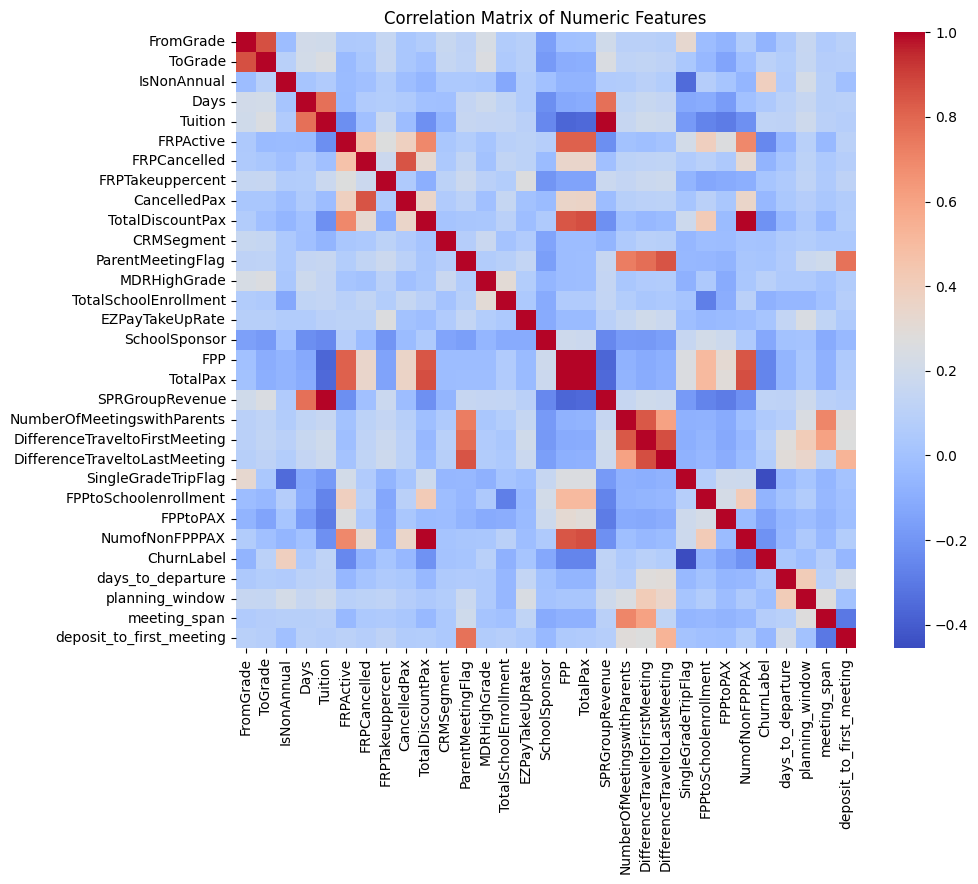

In [ ]:
import pandas as pd

# Filter for only integer and float columns
numeric_df = data.select_dtypes(include=['number'])

# Calculate the Pearson correlation matrix
corr_matrix = numeric_df.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Features")
plt.show()

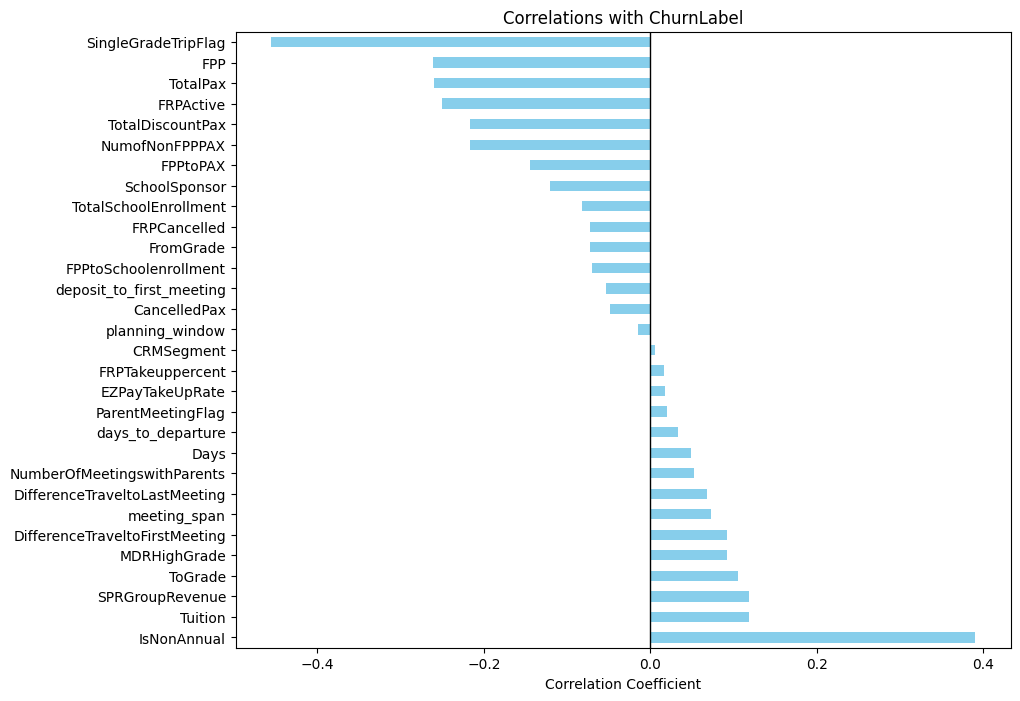

In [ ]:
target_corr = numeric_df.corr()['ChurnLabel'].sort_values(ascending=False)


target_corr = target_corr.drop('ChurnLabel')

plt.figure(figsize=(10, 8))
target_corr.plot(kind='barh', color='skyblue')
plt.title("Correlations with ChurnLabel")
plt.xlabel("Correlation Coefficient")
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.show()

## K-Nearest Neighbors

## Tree-Based Classification

In [ ]:
import os
import zipfile
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt


In [ ]:
def feature_engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    date_cols = [
        "DepartureDate", "ReturnDate", "DepositDate",
        "EarlyRPL", "LatestRPL", "InitialSystemDate",
        "FirstMeeting", "LastMeeting"
    ]

    # Parse to datetime + extract components
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], format="%m/%d/%y", errors="coerce")
            df[f"{col}_month"] = df[col].dt.month
            df[f"{col}_dow"] = df[col].dt.dayofweek
            df[f"{col}_year"] = df[col].dt.year

    # Time deltas
    if {"DepartureDate", "DepositDate"}.issubset(df.columns):
        df["days_to_departure"] = (df["DepartureDate"] - df["DepositDate"]).dt.days
    if {"DepartureDate", "InitialSystemDate"}.issubset(df.columns):
        df["planning_window"] = (df["DepartureDate"] - df["InitialSystemDate"]).dt.days
    if {"LastMeeting", "FirstMeeting"}.issubset(df.columns):
        df["meeting_span"] = (df["LastMeeting"] - df["FirstMeeting"]).dt.days
    if {"FirstMeeting", "DepositDate"}.issubset(df.columns):
        df["deposit_to_first_meeting"] = (df["FirstMeeting"] - df["DepositDate"]).dt.days
    if {"ReturnDate", "DepartureDate"}.issubset(df.columns):
        df["trip_length_from_dates"] = (df["ReturnDate"] - df["DepartureDate"]).dt.days

    # Grade range
    if {"ToGrade", "FromGrade"}.issubset(df.columns):
        df["grade_range"] = df["ToGrade"] - df["FromGrade"]

    # Simple rates (guard division by zero)
    if {"TotalDiscountPax", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["discount_pax_rate"] = df["TotalDiscountPax"] / denom

    if {"CancelledPax", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["cancel_pax_rate"] = df["CancelledPax"] / denom

    if {"FPP", "TotalPax"}.issubset(df.columns):
        denom = df["TotalPax"].replace(0, np.nan)
        df["fpp_rate"] = df["FPP"] / denom

    # Drop raw datetime columns (keep engineered numeric components)
    for col in date_cols:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    return df


df = feature_engineer(df_raw)

# Target: Retained = 1 (positive class), Churned = 0
y = df_raw["RetainedLabel"].map({"Retained": 1, "Churned": 0})
X = df.drop(columns=["RetainedLabel"], errors="ignore")

print("X shape after feature engineering:", X.shape)
y.value_counts()

# Identify categorical vs numeric predictors
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = [c for c in X.columns if c not in cat_cols]

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)

def evaluate_binary(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "auc": roc_auc_score(y_true, y_proba),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }

baseline_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
    max_features="sqrt",
)

baseline_model = Pipeline([
    ("preprocess", preprocess),
    ("rf", baseline_rf)
])

baseline_model.fit(X_train, y_train)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]
baseline_metrics = evaluate_binary(y_test, baseline_proba)

baseline_metrics

configs = [
    {"config":"baseline_balanced", "n_estimators":300, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"depth12_leaf2",     "n_estimators":300, "max_depth":12,   "min_samples_leaf":2, "min_samples_split":4, "max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"more_regularized",  "n_estimators":300, "max_depth":10,   "min_samples_leaf":5, "min_samples_split":10,"max_features":"sqrt", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"unweighted",        "n_estimators":300, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":True, "class_weight":None},
    {"config":"log2_features",     "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"log2", "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"half_features",     "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":0.5,    "bootstrap":True, "class_weight":"balanced_subsample"},
    {"config":"no_bootstrap",      "n_estimators":250, "max_depth":None, "min_samples_leaf":1, "min_samples_split":2, "max_features":"sqrt", "bootstrap":False,"class_weight":"balanced_subsample"},
]

rows = []
for cfg in configs:
    rf = RandomForestClassifier(
        n_estimators=cfg["n_estimators"],
        max_depth=cfg["max_depth"],
        min_samples_split=cfg["min_samples_split"],
        min_samples_leaf=cfg["min_samples_leaf"],
        max_features=cfg["max_features"],
        bootstrap=cfg["bootstrap"],
        class_weight=cfg["class_weight"],
        random_state=42,
        n_jobs=-1
    )

    model = Pipeline([("preprocess", preprocess), ("rf", rf)])
    model.fit(X_train, y_train)

    proba = model.predict_proba(X_test)[:, 1]
    m = evaluate_binary(y_test, proba)

    rows.append({
        **cfg,
        "accuracy": m["accuracy"],
        "precision": m["precision"],
        "recall": m["recall"],
        "auc": m["auc"],
    })

rf_log = pd.DataFrame(rows).sort_values("accuracy", ascending=False)
rf_log

# Pick best hyperparameters by test accuracy (from the log above)
best_row = rf_log.iloc[0].to_dict()
best_row

best_rf = RandomForestClassifier(
    n_estimators=int(best_row["n_estimators"]),
    max_depth=None if pd.isna(best_row["max_depth"]) else int(best_row["max_depth"]),
    min_samples_split=int(best_row["min_samples_split"]),
    min_samples_leaf=int(best_row["min_samples_leaf"]),
    max_features=best_row["max_features"],
    bootstrap=bool(best_row["bootstrap"]),
    class_weight=best_row["class_weight"],
    random_state=42,
    n_jobs=-1
)

best_model = Pipeline([
    ("preprocess", preprocess),
    ("rf", best_rf)
])

best_model.fit(X_train, y_train)
best_proba = best_model.predict_proba(X_test)[:, 1]
best_metrics = evaluate_binary(y_test, best_proba)

best_metrics

cm = best_metrics["confusion_matrix"]
cm

# ---- Feature importance (top 20) ----
pre = best_model.named_steps["preprocess"]
ohe = pre.named_transformers_["cat"].named_steps["onehot"]

feature_names = np.concatenate([
    np.array(num_cols, dtype=object),
    ohe.get_feature_names_out(cat_cols)
])

importances = best_model.named_steps["rf"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances}).sort_values("importance", ascending=False)

top_k = 20
display(imp_df.head(top_k))

plt.figure(figsize=(8, 7))
plt.barh(imp_df.head(top_k)["feature"][::-1], imp_df.head(top_k)["importance"][::-1])
plt.title("Random Forest Feature Importance (Top 20)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Refit on ALL labeled data (recommended before producing submission)
best_model.fit(X, y)

# Feature engineer unlabeled data the same way
df_pred = feature_engineer(df_pred_raw)
X_pred = df_pred.drop(columns=["RetainedLabel"], errors="ignore")

pred_proba = best_model.predict_proba(X_pred)[:, 1]
pred_label = np.where(pred_proba >= 0.5, "Retained", "Churned")

prediction_submission = pd.DataFrame({"RetainedLabel": pred_label})
prediction_submission.head()

# Write the required file
OUT_PATH = "prediction_submission.csv"
prediction_submission.to_csv(OUT_PATH, index=False)

print("Wrote:", OUT_PATH)
print(prediction_submission["RetainedLabel"].value_counts())

NameError: name 'pd' is not defined

## New Method Classification: Gaussian Process Classifier


In [ ]:
#libraries
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF, Matern, RationalQuadratic, ConstantKernel as C
from sklearn.datasets import make_moons
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score
from sklearn.inspection import permutation_importance

Feature Selection - figure out which features to place in GPC model

In [ ]:
# Make a copy of data
data_feature_section = data.copy()

Rank features by mututal importance

In [ ]:
# Remove datetime columns
data_feature_section_mi = data_feature_section.select_dtypes(exclude=['datetime'])

# Create dummy variables for categorical variables
data_feature_section_mi = pd.get_dummies(data_feature_section_mi, drop_first=True)
# Define features (X) and target (y) of the whole dataset
X = data_feature_section_mi.drop("RetainedLabel", axis=1)
y = data_feature_section_mi["RetainedLabel"]

In [ ]:
# Filter features by mutual information
# MI measures the amount of shared information between two random variables
mi = mutual_info_classif(X, y)

# Combine scores with column names
mi_series = pd.Series(mi, index=X.columns)

# Sort features by importance (descending)
mi_series = mi_series.sort_values(ascending=False)

# View top 10 features
print(mi_series.head(10))

FromGrade              0.098527
SingleGradeTripFlag    0.095841
IsNonAnnual            0.069723
SPRNewExisting_NEW     0.064977
FPP                    0.061237
TotalPax               0.052680
EZPayTakeUpRate        0.043854
FRPActive              0.043756
NumofNonFPPPAX         0.041120
FPPtoPAX               0.038429
dtype: float64


I have create a list of features that I would like to explore visually:
* days_to_departure
* planning_window
* meeting_span
* IncomeLevel
* TotalSchoolEnrollment
* DepartureMonth
* IsNonAnnual
* Tuition
* SingleGradeTripFlag
* SPRNewExisting
* FPP
* FRPActive

In [ ]:
#functions to create visiualization to compare the features against the RetainedLabel
#function to create boxplot
def boxplot_retention(feature, feature_label):

  sns.boxplot(x='RetainedLabel', y=feature, data=data_feature_section)
  plt.title(feature_label + ' by Retention Category')
  plt.show()

#function to create histogram
def histplot_retention(feature, feature_label):

  sns.histplot(data=data_feature_section, x=feature, hue='RetainedLabel', element='step', stat='density', common_norm=False)
  plt.title(feature_label + ' Distribution by Retention Category')
  plt.show()

def barplot_bin_retention(feature, feature_label, bins_num):

  # Bin days_to_departure
  data_feature_section['bins'] = pd.cut(data_feature_section[feature], bins=bins_num)

  # Compute retention rate per bin
  retention_rate = data_feature_section.groupby('bins')['RetainedLabel'].mean().reset_index()

  # Compute overall average retention
  overall_avg = data_feature_section['RetainedLabel'].mean()

  # Plot barplot
  sns.barplot(x='bins', y='RetainedLabel', data=retention_rate)
  plt.xticks(rotation=45)
  plt.ylabel('Retention Rate')
  plt.title('Retention Rate by ' + feature_label)

  # Add average line
  plt.axhline(overall_avg, color='red', linestyle='--', label=f'Overall Avg: {overall_avg:.2f}')
  plt.legend()

  plt.show()

def countplot_retention(feature, feature_label):

  sns.countplot(x=feature, hue='RetainedLabel', data=data_feature_section)
  plt.xticks(rotation=45)
  plt.ylabel('Count')
  plt.title('Retention by ' + feature_label)
  plt.show()


/tmp/ipython-input-186/2770065007.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  retention_rate = data_feature_section.groupby('bins')['RetainedLabel'].mean().reset_index()


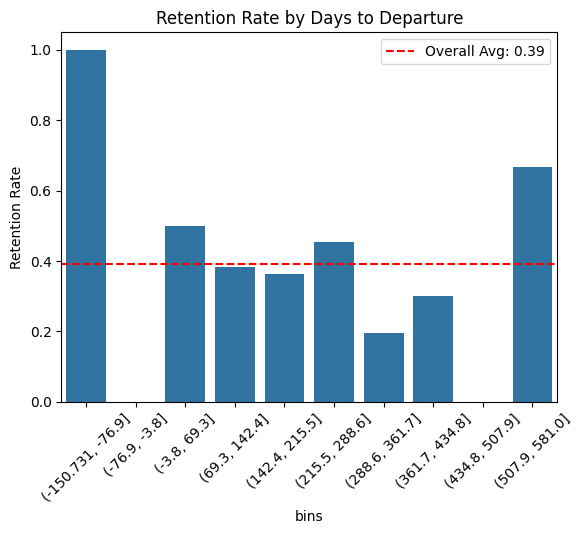

In [ ]:
barplot_bin_retention('days_to_departure', 'Days to Departure', 10)

barplot_bin_retention('planning_window', 'Planning Window', 10)

boxplot_retention('meeting_span', 'Meeting Span')

countplot_retention('IncomeLevel', 'Income Level')

histplot_retention('TotalSchoolEnrollment', 'Total School Enrollment')

countplot_retention('DepartureMonth', 'Departure Month')

countplot_retention('IsNonAnnual', 'Is Non Annual')

barplot_bin_retention('Tuition', 'Tuition', 10)

countplot_retention('SingleGradeTripFlag', 'Single Grade Trip Flag')

countplot_retention('SPRNewExisting', 'SPR New Existing')

histplot_retention('FPP', 'FPP')

histplot_retention('FRPActive', 'FRP Active')

I chose to select the following columns:
* planning_window
* TotalSchoolEnrollment
* DepartureMonth
* IsNonAnnual
* Tuition
* SingleGradeTripFlag
* SPRNewExisting
* FPP


In [ ]:
selected_columns = ["planning_window",
                    "TotalSchoolEnrollment",
                    "DepartureMonth",
                    "IsNonAnnual",
                    "Tuition",
                    "SingleGradeTripFlag",
                    "SPRNewExisting",
                    "FPP",

                    "RetainedLabel"]

data_columns = data[selected_columns]

In [ ]:
# Convert categorical features to numerical using one-hot encoding
data_columns = pd.get_dummies(data_columns, drop_first=True)

# Define features (X) and target (y)
X = data_columns.drop("RetainedLabel", axis=1)
y = data_columns["RetainedLabel"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split the data into training and testing sets
#limit train size to 1000 so that the model runs faster during the debuging stage
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, train_size=1000, stratify=y, random_state=42)

In [ ]:
#takes 11 minutes to run

#use GridSeach to find the best hyperparameters
param_grid = {
    "kernel": [
        1.0 * RBF(),
        1.0 * Matern(nu=1.5),
        1.0 * Matern(nu=5.5),
        1.0 * RationalQuadratic()
    ],
    "n_restarts_optimizer": [0, 5]
}

gpc = GaussianProcessClassifier(random_state=42)

grid = GridSearchCV(
    gpc,
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)


{'kernel': 1**2 * Matern(length_scale=1, nu=1.5), 'n_restarts_optimizer': 0}
0.7700000000000001


GPC Accuracy: 0.8120950323974082

GPC Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       844
           1       0.80      0.70      0.74       545

    accuracy                           0.81      1389
   macro avg       0.81      0.79      0.80      1389
weighted avg       0.81      0.81      0.81      1389



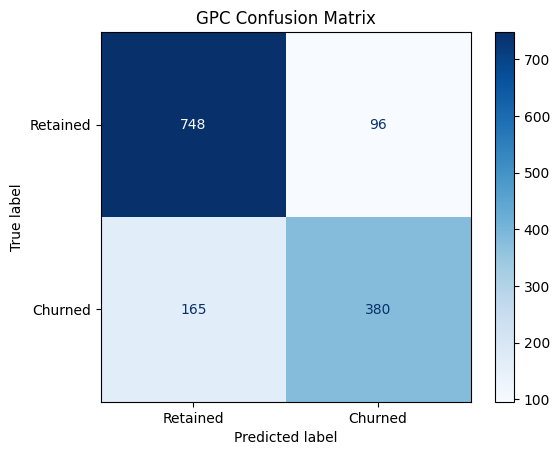

In [ ]:
# Define the Gaussian Process kernel
# Kernel = Constant * RBF
kernel = C(1.0) * Matern(length_scale=1, nu=1.5)

# Initialize the Gaussian Process Classifier
gpc = GaussianProcessClassifier(kernel=kernel, random_state=42, n_restarts_optimizer=0)

# Fit the model
gpc.fit(X_train, y_train)

# Make predictions
gpc_y_pred = gpc.predict(X_test)

# Evaluate the model
print("GPC Accuracy:", accuracy_score(y_test, gpc_y_pred))
print("\nGPC Classification Report:\n", classification_report(y_test, gpc_y_pred))

cm = confusion_matrix(y_test, gpc_y_pred)

# Create the confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])

# Plot the confusion matrix
disp.plot(cmap='Blues')
plt.title('GPC Confusion Matrix')
plt.show()

In [ ]:
# Split the data into training and testing sets
# use test_size = 0.2 to fit the model on more of the training data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, stratify=y, random_state=42)

GPC Accuracy: 0.8326359832635983

GPC Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       290
           1       0.81      0.75      0.78       188

    accuracy                           0.83       478
   macro avg       0.83      0.82      0.82       478
weighted avg       0.83      0.83      0.83       478



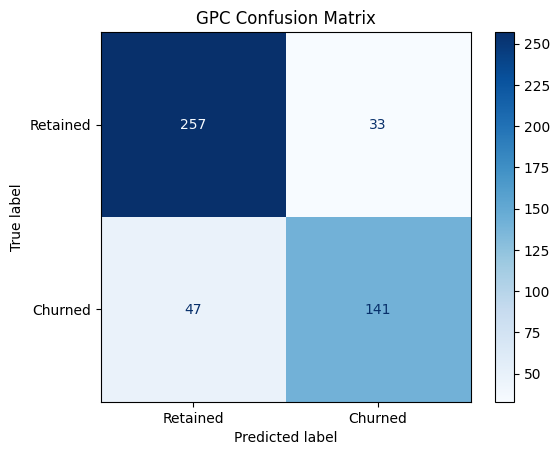

In [ ]:
# This model is run on a larger sample of training data and will take a minute to run
# model will provide me with the key metrics for the best gpc model
# Kernel = Constant * RBF
kernel = C(1.0) * Matern(length_scale=1, nu=1.5)

# Initialize the Gaussian Process Classifier
gpc = GaussianProcessClassifier(kernel=kernel, random_state=42, n_restarts_optimizer=0)

# Fit the model
gpc.fit(X_train, y_train)

# Make predictions
gpc_y_pred = gpc.predict(X_test)

# Evaluate the model
print("GPC Accuracy:", accuracy_score(y_test, gpc_y_pred))
print("\nGPC Classification Report:\n", classification_report(y_test, gpc_y_pred))

cm = confusion_matrix(y_test, gpc_y_pred)

# Create the confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Retained', 'Churned'])

# Plot the confusion matrix
disp.plot(cmap='Blues')
plt.title('GPC Confusion Matrix')
plt.show()

In [ ]:
#calclate the ROC AUC of the gpc model
y_prob = gpc.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)
print("ROC AUC:", auc)

ROC AUC: 0.8879677182685253


In [ ]:
# Variable Importance Plot
# Based of permutation importance: shuffle one feature at a time and measure how much model performance drops
# Score based off ROC AUC
result = permutation_importance(
    gpc,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)


importances = pd.Series(result.importances_mean, index=X.columns)
importances = importances.sort_values(ascending=False)

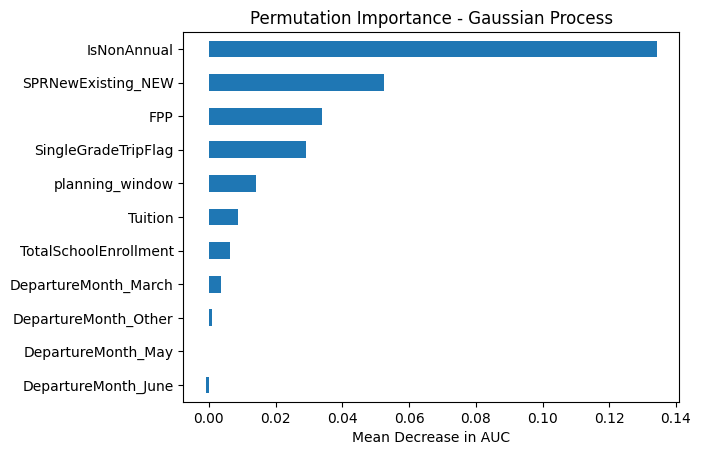

In [ ]:
importances.plot(kind='barh')
plt.xlabel("Mean Decrease in AUC")
plt.title("Permutation Importance - Gaussian Process")
plt.gca().invert_yaxis()
plt.show()

## Make Predictions on Unknown Data

In [ ]:
# Create the final model using all of the data
selected_columns = ["planning_window",
                    "TotalSchoolEnrollment",
                    "DepartureMonth",
                    "IsNonAnnual",
                    "Tuition",
                    "SingleGradeTripFlag",
                    "SPRNewExisting",
                    "FPP",

                    "RetainedLabel"]

data_columns = data[selected_columns]

# Convert categorical features to numerical using one-hot encoding
data_columns = pd.get_dummies(data_columns, drop_first=True)

# Define features (X) and target (y)
X = data_columns.drop("RetainedLabel", axis=1)
y = data_columns["RetainedLabel"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Kernel = Constant * RBF
kernel = C(1.0) * Matern(length_scale=1, nu=1.5)

# Initialize the Gaussian Process Classifier
gpc = GaussianProcessClassifier(kernel=kernel, random_state=42, n_restarts_optimizer=0)

# Fit on gpc model
gpc.fit(X_scaled, y)


GaussianProcessClassifier(kernel=1**2 * Matern(length_scale=1, nu=1.5),
                          random_state=42)

In [ ]:
prediction_data = pd.read_csv('https://www.dropbox.com/scl/fi/hveyqinjaurpm2e1s5uh2/scholastic_travel_predictions.csv?rlkey=3sx0cjmaubjafwripmcsfhktd&st=lbb9ii3b&dl=1')

prediction_data.head()

,ProgramCode,FromGrade,ToGrade,GroupState,IsNonAnnual,Days,TravelType,DepartureDate,ReturnDate,DepositDate,...,GroupGradeTypeLow,GroupGradeTypeHigh,GroupGradeType,MajorProgramCode,SingleGradeTripFlag,FPPtoSchoolenrollment,FPPtoPAX,NumofNonFPPPAX,SchoolSizeIndicator,RetainedLabel
0,HD,8,8,FL,0,3,A,1/15/11,1/17/11,10/15/10,...,Middle,Middle,Middle->Middle,H,1,0.025131,0.888889,3,L,NaN
1,Other,9,9,Other,0,8,A,1/24/11,1/31/11,10/1/10,...,Undefined,Undefined,Undefined->Undefined,Other,1,0.000000,0.928571,1,FIXED_NA,NaN
2,Other,8,8,AZ,0,8,A,1/29/11,2/5/11,6/1/10,...,Middle,High,Middle->High,C,1,0.104000,0.928571,4,S-M,NaN
3,HD,8,8,TX,0,4,A,2/7/11,2/10/11,10/25/10,...,PK,Middle,PK->Middle,H,1,0.103937,0.916667,6,M-L,NaN
4,HD,5,5,CA,0,6,A,2/13/11,2/18/11,10/15/10,...,Undefined,Undefined,Undefined->Undefined,H,1,0.000000,0.891892,4,FIXED_NA,NaN


In [ ]:
for col in date_cols:
    prediction_data[col] = pd.to_datetime(prediction_data[col], format="%m/%d/%y", errors="coerce")

In [ ]:
prediction_data["days_to_departure"] = (prediction_data["DepartureDate"] - prediction_data["DepositDate"]).dt.days
prediction_data["planning_window"] = (prediction_data["DepartureDate"] - prediction_data["InitialSystemDate"]).dt.days
prediction_data["meeting_span"] = (prediction_data["LastMeeting"] - prediction_data["FirstMeeting"]).dt.days
prediction_data["deposit_to_first_meeting"] = (prediction_data["FirstMeeting"] - prediction_data["DepositDate"]).dt.days

In [ ]:
prediction_data = prediction_data[selected_columns]

prediction_data = pd.get_dummies(prediction_data, drop_first=True)

X_pred = prediction_data.drop('RetainedLabel', axis=1)

# make sure we have the same columns in this dataset as in training
training_features = X.columns
X_pred = X_pred.reindex(columns=training_features, fill_value=0)

scaler = StandardScaler()
X_pred = scaler.fit_transform(X_pred)

In [ ]:
# Add the predictions to the prediction_data DataFrame
prediction_data['RetainedLabel'] = gpc.predict(X_pred)
mapping = {0: 'Retained', 1: 'Churned'}
data['RetainedLabel'] = data['RetainedLabel'].map(mapping)

In [ ]:
# Save files

prediction_data.to_csv('Classification Project Predictions.csv', index=False)
files.download('Classification Project Predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>